In [3]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

DATASET_PATH = "road_dataset"
IMG_SIZE = 128

X = []
y_binary = []
y_multi = []

class_names = ['good', 'satisfactory', 'poor', 'very_poor']

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X.append(img)

        # Binary label
        if class_name == "good":
            y_binary.append(0)   # No pothole
        else:
            y_binary.append(1)   # Pothole exists

        # Multi-class label
        if class_name != "good":
            if class_name == "satisfactory":
                y_multi.append(0)
            elif class_name == "poor":
                y_multi.append(1)
            else:
                y_multi.append(2)

X = np.array(X)
y_binary = np.array(y_binary)

# Multi only for pothole images
X_multi = X[y_binary == 1]
y_multi = to_categorical(y_multi, 3)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_binary_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
def build_multi_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
fold = 1

for train_idx, val_idx in kfold.split(X):
    print(f"\nBinary Training Fold {fold}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_binary[train_idx], y_binary[val_idx]

    model_bin = build_binary_model()

    model_bin.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=16
    )

    model_bin.save(f"binary_model_fold_{fold}.h5")

    fold += 1


Binary Training Fold 1


c:\Users\KIIT0001\anaconda3\envs\myenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 43s 169ms/step - accuracy: 0.9145 - loss: 0.2242 - val_accuracy: 0.9744 - val_loss: 0.0932
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 78s 319ms/step - accuracy: 0.9692 - loss: 0.0889 - val_accuracy: 0.9795 - val_loss: 0.0692
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 46s 187ms/step - accuracy: 0.9764 - loss: 0.0620 - val_accuracy: 0.9805 - val_loss: 0.0547
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 49s 199ms/step - accuracy: 0.9784 - loss: 0.0630 - val_accuracy: 0.9826 - val_loss: 0.0441
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 55s 224ms/step - accuracy: 0.9895 - loss: 0.0362 - val_accuracy: 0.9713 - val_loss: 0.0678
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 35s 143ms/step - accuracy: 0.9897 - loss: 0.0315 - val_accuracy: 0.9826 - val_loss: 0.0698
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 43s 174ms/step - accuracy: 0.9833 - loss: 0.0518 - val_accuracy: 0.9938 - val_loss: 0.0264
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 61s 250ms/step - accuracy: 0.9851 - loss: 0


Binary Training Fold 2
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 56s 212ms/step - accuracy: 0.9338 - loss: 0.1783 - val_accuracy: 0.9538 - val_loss: 0.1335
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 59s 242ms/step - accuracy: 0.9682 - loss: 0.0813 - val_accuracy: 0.9867 - val_loss: 0.0391
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 59s 148ms/step - accuracy: 0.9784 - loss: 0.0594 - val_accuracy: 0.9897 - val_loss: 0.0337
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 35s 144ms/step - accuracy: 0.9792 - loss: 0.0565 - val_accuracy: 0.9877 - val_loss: 0.0379
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 140ms/step - accuracy: 0.9815 - loss: 0.0526 - val_accuracy: 0.9938 - val_loss: 0.0322
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 138ms/step - accuracy: 0.9933 - loss: 0.0218 - val_accuracy: 0.9897 - val_loss: 0.0472
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 138ms/step - accuracy: 0.9928 - loss: 0.0303 - val_accuracy: 0.9867 - val_loss: 0.0327
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 33s 137ms/step - ac


Binary Training Fold 3
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 36s 140ms/step - accuracy: 0.9279 - loss: 0.1906 - val_accuracy: 0.9548 - val_loss: 0.0838
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 138ms/step - accuracy: 0.9620 - loss: 0.1047 - val_accuracy: 0.9743 - val_loss: 0.0579
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 35s 142ms/step - accuracy: 0.9674 - loss: 0.0770 - val_accuracy: 0.9867 - val_loss: 0.0507
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 37s 151ms/step - accuracy: 0.9797 - loss: 0.0605 - val_accuracy: 0.9825 - val_loss: 0.0388
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 43s 177ms/step - accuracy: 0.9838 - loss: 0.0486 - val_accuracy: 0.9867 - val_loss: 0.0442
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 50s 203ms/step - accuracy: 0.9885 - loss: 0.0356 - val_accuracy: 0.9671 - val_loss: 0.0933
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 100s 275ms/step - accuracy: 0.9887 - loss: 0.0317 - val_accuracy: 0.9877 - val_loss: 0.0287
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 42s 172ms/step - a


Binary Training Fold 4
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 38s 149ms/step - accuracy: 0.9310 - loss: 0.1769 - val_accuracy: 0.9630 - val_loss: 0.0844
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 37s 154ms/step - accuracy: 0.9630 - loss: 0.1000 - val_accuracy: 0.9610 - val_loss: 0.0932
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 37s 151ms/step - accuracy: 0.9749 - loss: 0.0747 - val_accuracy: 0.9815 - val_loss: 0.0534
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 37s 152ms/step - accuracy: 0.9861 - loss: 0.0461 - val_accuracy: 0.9805 - val_loss: 0.0515
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 37s 152ms/step - accuracy: 0.9833 - loss: 0.0499 - val_accuracy: 0.9795 - val_loss: 0.0484
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 38s 157ms/step - accuracy: 0.9900 - loss: 0.0298 - val_accuracy: 0.9877 - val_loss: 0.0390
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 36s 149ms/step - accuracy: 0.9915 - loss: 0.0279 - val_accuracy: 0.9897 - val_loss: 0.0406
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 43s 177ms/step - ac


Binary Training Fold 5
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.9292 - loss: 0.1813 - val_accuracy: 0.9733 - val_loss: 0.0742
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 50s 205ms/step - accuracy: 0.9692 - loss: 0.0849 - val_accuracy: 0.9774 - val_loss: 0.0562
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 57s 233ms/step - accuracy: 0.9731 - loss: 0.0669 - val_accuracy: 0.9867 - val_loss: 0.0357
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 53s 217ms/step - accuracy: 0.9810 - loss: 0.0530 - val_accuracy: 0.9723 - val_loss: 0.0702
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 37s 153ms/step - accuracy: 0.9826 - loss: 0.0578 - val_accuracy: 0.9908 - val_loss: 0.0190
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 138ms/step - accuracy: 0.9890 - loss: 0.0289 - val_accuracy: 0.9928 - val_loss: 0.0198
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 141ms/step - accuracy: 0.9890 - loss: 0.0318 - val_accuracy: 0.9784 - val_loss: 0.0475
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 139ms/step - ac

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [9]:
def get_callbacks(model_name, fold):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=f"{model_name}_fold_{fold}.h5",
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

In [10]:
fold = 1

for train_idx, val_idx in kfold.split(X_multi):
    print(f"\n🔹 Multi-Class Training Fold {fold}")

    X_train, X_val = X_multi[train_idx], X_multi[val_idx]
    y_train, y_val = y_multi[train_idx], y_multi[val_idx]

    model_multi = build_multi_model()

    callbacks = get_callbacks("multi_model", fold)

    model_multi.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=16,
        callbacks=callbacks
    )

    fold += 1


🔹 Multi-Class Training Fold 1
Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7587 - loss: 0.5938
Epoch 1: val_accuracy improved from None to 0.89356, saving model to multi_model_fold_1.h5


190/190 ━━━━━━━━━━━━━━━━━━━━ 31s 156ms/step - accuracy: 0.8309 - loss: 0.4393 - val_accuracy: 0.8936 - val_loss: 0.2562 - learning_rate: 0.0010
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9135 - loss: 0.2298
Epoch 2: val_accuracy improved from 0.89356 to 0.90802, saving model to multi_model_fold_1.h5


190/190 ━━━━━━━━━━━━━━━━━━━━ 28s 149ms/step - accuracy: 0.9095 - loss: 0.2388 - val_accuracy: 0.9080 - val_loss: 0.2214 - learning_rate: 0.0010
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9067 - loss: 0.2517
Epoch 3: val_accuracy improved from 0.90802 to 0.91984, saving model to multi_model_fold_1.h5


190/190 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - accuracy: 0.9141 - loss: 0.2260 - val_accuracy: 0.9198 - val_loss: 0.1823 - learning_rate: 0.0010
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9371 - loss: 0.1607
Epoch 4: val_accuracy improved from 0.91984 to 0.92247, saving model to multi_model_fold_1.h5


190/190 ━━━━━━━━━━━━━━━━━━━━ 28s 145ms/step - accuracy: 0.9349 - loss: 0.1666 - val_accuracy: 0.9225 - val_loss: 0.2144 - learning_rate: 0.0010
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9484 - loss: 0.1379
Epoch 5: val_accuracy did not improve from 0.92247
190/190 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - accuracy: 0.9401 - loss: 0.1508 - val_accuracy: 0.9225 - val_loss: 0.1786 - learning_rate: 0.0010
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9541 - loss: 0.1174
Epoch 6: val_accuracy improved from 0.92247 to 0.93561, saving model to multi_model_fold_1.h5


...

191/191 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - accuracy: 0.9267 - loss: 0.1881 - val_accuracy: 0.9039 - val_loss: 0.2310 - learning_rate: 0.0010
Epoch 4/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9124 - loss: 0.2183
Epoch 4: val_accuracy improved from 0.90395 to 0.92105, saving model to multi_model_fold_5.h5


191/191 ━━━━━━━━━━━━━━━━━━━━ 27s 142ms/step - accuracy: 0.9277 - loss: 0.1820 - val_accuracy: 0.9211 - val_loss: 0.1913 - learning_rate: 0.0010
Epoch 5/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9378 - loss: 0.1480
Epoch 5: val_accuracy did not improve from 0.92105
191/191 ━━━━━━━━━━━━━━━━━━━━ 27s 140ms/step - accuracy: 0.9411 - loss: 0.1415 - val_accuracy: 0.9184 - val_loss: 0.2364 - learning_rate: 0.0010
Epoch 6/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9403 - loss: 0.1511
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 6: val_accuracy improved from 0.92105 to 0.93684, saving model to multi_model_fold_5.h5


191/191 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - accuracy: 0.9510 - loss: 0.1281 - val_accuracy: 0.9368 - val_loss: 0.2401 - learning_rate: 0.0010
Epoch 7/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9723 - loss: 0.0783
Epoch 7: val_accuracy improved from 0.93684 to 0.94079, saving model to multi_model_fold_5.h5


191/191 ━━━━━━━━━━━━━━━━━━━━ 27s 140ms/step - accuracy: 0.9757 - loss: 0.0646 - val_accuracy: 0.9408 - val_loss: 0.2147 - learning_rate: 3.0000e-04
Epoch 8/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9786 - loss: 0.0554
Epoch 8: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 8: val_accuracy improved from 0.94079 to 0.94342, saving model to multi_model_fold_5.h5


191/191 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.9776 - loss: 0.0575 - val_accuracy: 0.9434 - val_loss: 0.2173 - learning_rate: 3.0000e-04
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.


In [11]:
from tensorflow.keras.models import load_model

val_accuracies = []

for fold in range(1, 6):
    print(f"\nEvaluating Fold {fold}")

    model = load_model(f"binary_model_fold_{fold}.h5")

    # Use SAME validation split logic
    _, val_idx = list(kfold.split(X))[fold-1]
    X_val = X[val_idx]
    y_val = y_binary[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Fold 1


Fold 1 Accuracy: 0.9918

Evaluating Fold 2


Fold 2 Accuracy: 0.9949

Evaluating Fold 3


Fold 3 Accuracy: 0.9938

Evaluating Fold 4


Fold 4 Accuracy: 0.9836

Evaluating Fold 5
Fold 5 Accuracy: 0.9979


In [12]:
import numpy as np

print("\nFinal Cross-Validation Accuracy:")
print("Mean Accuracy:", np.mean(val_accuracies))
print("Std Dev:", np.std(val_accuracies))


Final Cross-Validation Accuracy:
Mean Accuracy: 0.9924041628837585
Std Dev: 0.004841607716869979


In [13]:
from tensorflow.keras.models import load_model
import numpy as np

val_accuracies_multi = []

for fold in range(1, 6):
    print(f"\nEvaluating Multi-Class Fold {fold}")

    model = load_model(f"multi_model_fold_{fold}.h5")

    # Get same validation split
    _, val_idx = list(kfold.split(X_multi))[fold-1]
    
    X_val = X_multi[val_idx]
    y_val = y_multi[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies_multi.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Multi-Class Fold 1


Fold 1 Accuracy: 0.9396

Evaluating Multi-Class Fold 2


Fold 2 Accuracy: 0.9539

Evaluating Multi-Class Fold 3


Fold 3 Accuracy: 0.9539

Evaluating Multi-Class Fold 4


Fold 4 Accuracy: 0.9408

Evaluating Multi-Class Fold 5
Fold 5 Accuracy: 0.9434


In [14]:
print("\nFinal Multi-Class Cross-Validation Accuracy:")
print("Mean Accuracy:", np.mean(val_accuracies_multi))
print("Std Dev:", np.std(val_accuracies_multi))


Final Multi-Class Cross-Validation Accuracy:
Mean Accuracy: 0.9463316917419433
Std Dev: 0.006342443763502447


In [15]:
import matplotlib.pyplot as plt

In [16]:
from tensorflow.keras.models import load_model

val_accuracies = []

for fold in range(1, 6):
    print(f"\nEvaluating Fold {fold}")

    model = load_model(f"binary_model_fold_{fold}.h5")

    _, val_idx = list(kfold.split(X))[fold-1]
    X_val = X[val_idx]
    y_val = y_binary[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Fold 1


Fold 1 Accuracy: 0.9918

Evaluating Fold 2
Fold 2 Accuracy: 0.9949

Evaluating Fold 3


Fold 3 Accuracy: 0.9938

Evaluating Fold 4


Fold 4 Accuracy: 0.9836

Evaluating Fold 5
Fold 5 Accuracy: 0.9979


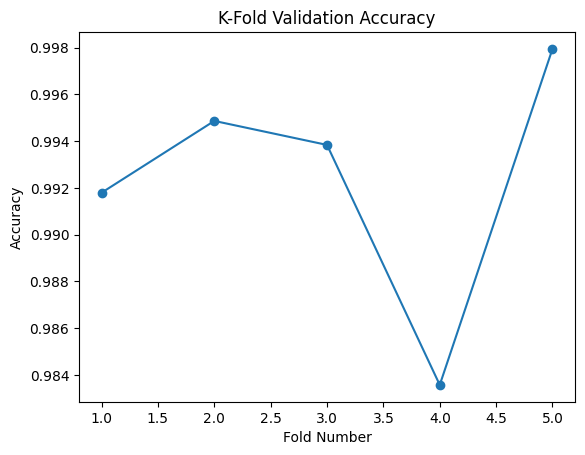

In [17]:
import matplotlib.pyplot as plt

folds = list(range(1, len(val_accuracies)+1))

plt.figure()
plt.plot(folds, val_accuracies, marker='o')

plt.title('K-Fold Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')

plt.show()

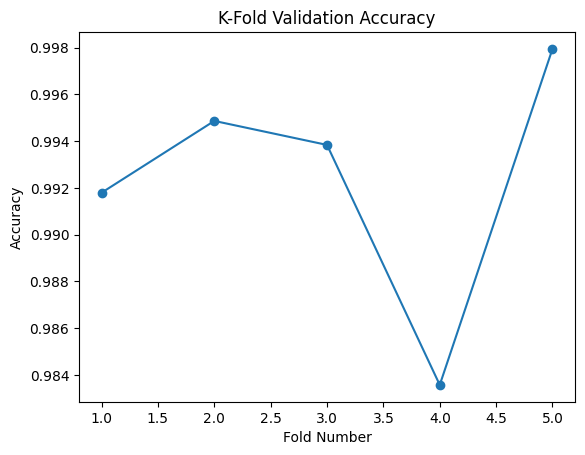

In [18]:
import matplotlib.pyplot as plt

folds = list(range(1, len(val_accuracies)+1))

plt.figure()
plt.plot(folds, val_accuracies, marker='o')

plt.title('K-Fold Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')

plt.show()

In [19]:
from tensorflow.keras.models import load_model

val_accuracies = []

for fold in range(1, 6):
    model = load_model(f"binary_model_fold_{fold}.h5")

    _, val_idx = list(kfold.split(X))[fold-1]
    X_val = X[val_idx]
    y_val = y_binary[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)
    val_accuracies.append(acc)

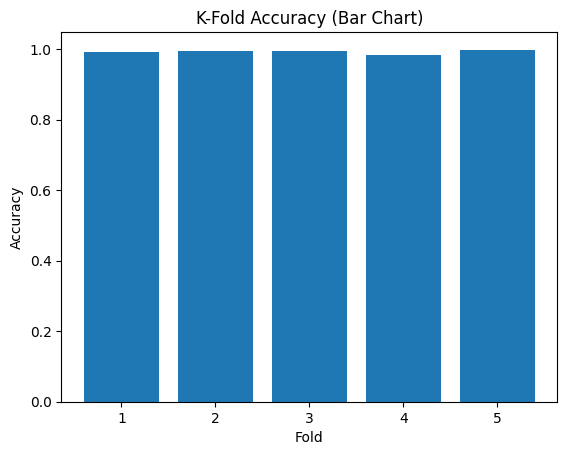

In [20]:
plt.figure()
plt.bar(folds, val_accuracies)

plt.title('K-Fold Accuracy (Bar Chart)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')

plt.show()

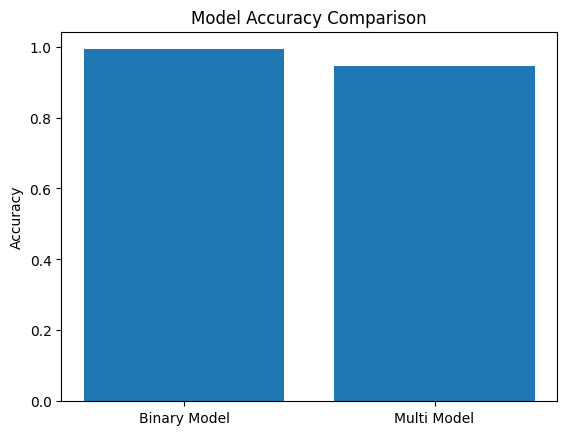

In [21]:
labels = ['Binary Model', 'Multi Model']
accuracies = [np.mean(val_accuracies), np.mean(val_accuracies_multi)]

plt.figure()
plt.bar(labels, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step


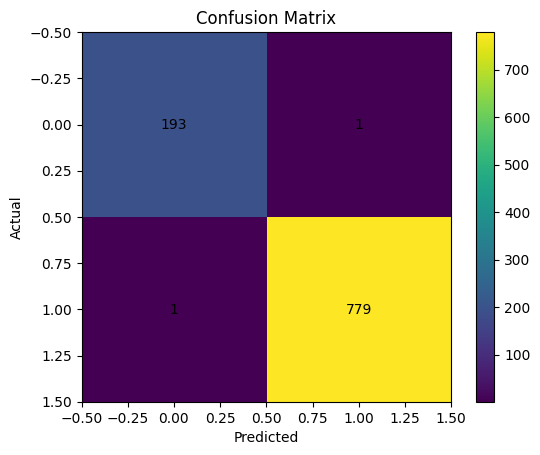

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_val)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [23]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

DATASET_PATH = "road_dataset"
IMG_SIZE = 128

X = []
y_binary = []

class_names = ['good', 'satisfactory', 'poor', 'very_poor']

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X.append(img)

        if class_name == "good":
            y_binary.append(0)
        else:
            y_binary.append(1)

X = np.array(X)
y_binary = np.array(y_binary)

In [26]:
from tensorflow.keras.models import load_model

val_accuracies = []

for fold in range(1, 6):
    print(f"\nEvaluating Fold {fold}")

    model = load_model(f"binary_model_fold_{fold}.h5")

    _, val_idx = list(kfold.split(X))[fold-1]
    X_val = X[val_idx]
    y_val = y_binary[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Fold 1


Fold 1 Accuracy: 0.9918

Evaluating Fold 2


Fold 2 Accuracy: 0.9949

Evaluating Fold 3


Fold 3 Accuracy: 0.9938

Evaluating Fold 4


Fold 4 Accuracy: 0.9836

Evaluating Fold 5
Fold 5 Accuracy: 0.9979


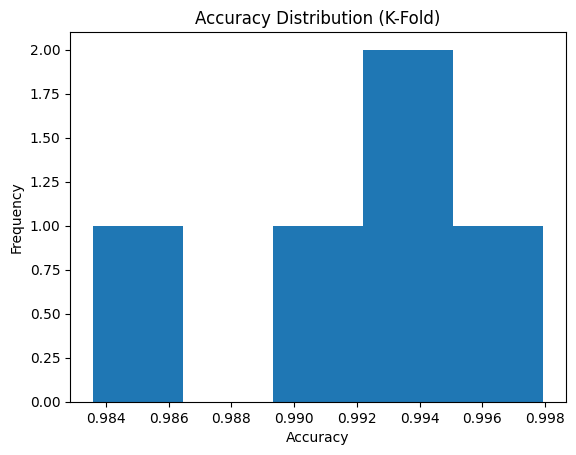

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(val_accuracies, bins=5)

plt.title("Accuracy Distribution (K-Fold)")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")

plt.show()

In [28]:
print("Binary:", val_accuracies)
print("Multi:", val_accuracies_multi)

Binary: [0.9917948842048645, 0.9948665499687195, 0.9938398599624634, 0.9835729002952576, 0.9979466199874878]
Multi: [0.9395532011985779, 0.9539473652839661, 0.9539473652839661, 0.9407894611358643, 0.9434210658073425]


In [30]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

DATASET_PATH = "road_dataset"
IMG_SIZE = 128

X_multi = []
y_multi = []

class_names = ['satisfactory', 'poor', 'very_poor']

for label, class_name in enumerate(class_names):
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X_multi.append(img)
        y_multi.append(label)

X_multi = np.array(X_multi)
y_multi = to_categorical(y_multi, num_classes=3)

In [31]:
from tensorflow.keras.models import load_model
import numpy as np

val_accuracies_multi = []

for fold in range(1, 6):
    print(f"\nEvaluating Multi-Class Fold {fold}")

    model = load_model(f"multi_model_fold_{fold}.h5")

    # Get same validation split
    _, val_idx = list(kfold.split(X_multi))[fold-1]
    
    X_val = X_multi[val_idx]
    y_val = y_multi[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies_multi.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Multi-Class Fold 1


Fold 1 Accuracy: 0.9396

Evaluating Multi-Class Fold 2


Fold 2 Accuracy: 0.9539

Evaluating Multi-Class Fold 3


Fold 3 Accuracy: 0.9539

Evaluating Multi-Class Fold 4


Fold 4 Accuracy: 0.9408

Evaluating Multi-Class Fold 5
Fold 5 Accuracy: 0.9434


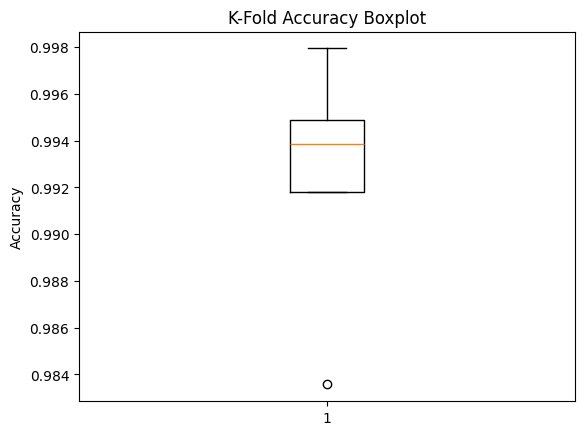

In [32]:
plt.figure()
plt.boxplot(val_accuracies)

plt.title("K-Fold Accuracy Boxplot")
plt.ylabel("Accuracy")

plt.show()

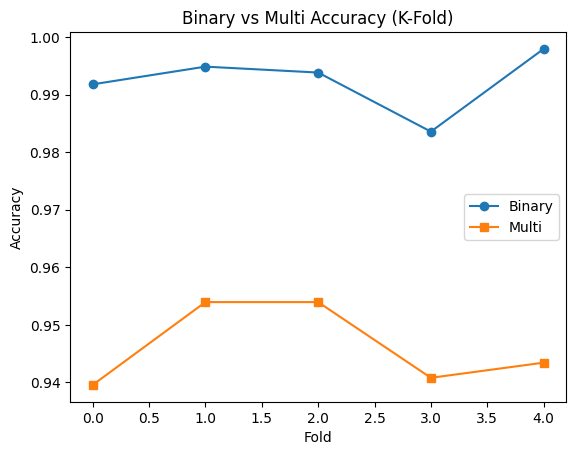

In [33]:
plt.figure()

plt.plot(val_accuracies, marker='o', label='Binary')
plt.plot(val_accuracies_multi, marker='s', label='Multi')

plt.title("Binary vs Multi Accuracy (K-Fold)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_val, axis=1)

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step
Accuracy: 0.9434210526315789
Precision: 0.9451884777443362
Recall: 0.9434210526315789
F1 Score: 0.9441616305594192

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       111
           1       0.87      0.89      0.88       158
           2       1.00      0.98      0.99       491

    accuracy                           0.94       760
   macro avg       0.90      0.91      0.90       760
weighted avg       0.95      0.94      0.94       760



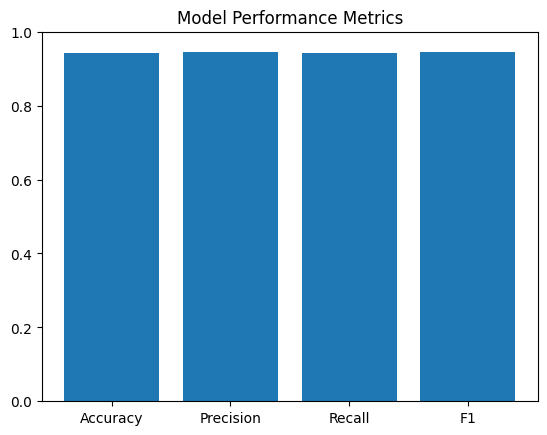

In [36]:
labels = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [acc, prec, rec, f1]

plt.figure()
plt.bar(labels, values)

plt.title("Model Performance Metrics")
plt.ylim(0,1)

plt.show()

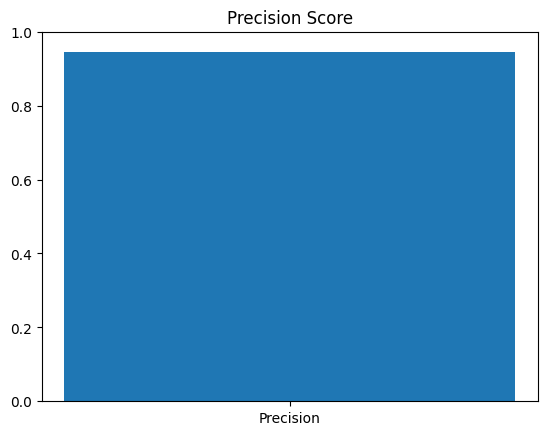

In [38]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(['Precision'], [prec])

plt.title("Precision Score")
plt.ylim(0,1)

plt.show()

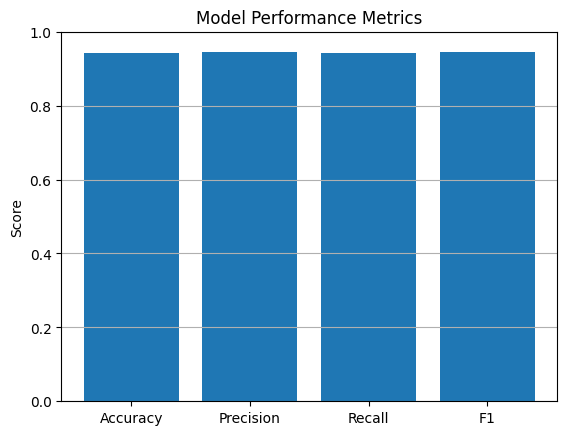

In [39]:
labels = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [acc, prec, rec, f1]

plt.figure()
plt.bar(labels, values)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y')

plt.show()